# Gaussian Naive Bayes on the Covertype Dataset

Implementation of a Gaussian Naive Bayes classifier on the Covertype dataset.

## Procedure
- Load and preprocess the dataset
- Train a baseline Gaussian Naive Bayes model
- Evaluate performance using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Confusion matrix
- Analyze performance across classes
- Improve the model by tuning `var_smoothing`

## Challenges 
- Naive Bayes is not suitable for binary classes, so the current model trains and tests on only the continuous features to allow for a more valid representation, 

Class Imbalance leads to the model predominantly guessing the first two classes. Class priors were implemented to balance the dataset and provide Naive Bayes with a uniform distribution following the baseline model. 

In [107]:
%pip install numpy pandas matplotlib scikit-learn ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)

In [109]:
# fetch dataset 
covertype = fetch_ucirepo(id=31) 
  
# data (as pandas dataframes) 
X = covertype.data.features 
y = covertype.data.targets 

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

continuous_cols = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

X_cont = X[continuous_cols].copy()

print("Continuous feature shape:", X_cont.shape)
display(X_cont.head())
  
# metadata 
print(covertype.metadata) 
  
# variable information 
print(covertype.variables)

Continuous feature shape: (581012, 10)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
0,2596,51,3,258,0,510,221,232,148,6279
1,2590,56,2,212,-6,390,220,235,151,6225
2,2804,139,9,268,65,3180,234,238,135,6121
3,2785,155,18,242,118,3090,238,238,122,6211
4,2595,45,2,153,-1,391,220,234,150,6172


{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [110]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)

def evaluate_model(model, X_eval, y_eval, label="Set"):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)

    acc = accuracy_score(y_eval, y_pred)
    prec_macro = precision_score(y_eval, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_eval, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_eval, y_pred, average="macro", zero_division=0)

    prec_weighted = precision_score(y_eval, y_pred, average="weighted", zero_division=0)
    rec_weighted = recall_score(y_eval, y_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_eval, y_pred, average="weighted", zero_division=0)

    loss = log_loss(y_eval, y_prob)

    print(f"{label} Accuracy:", acc)
    print(f"{label} Precision (Macro):", prec_macro)
    print(f"{label} Recall (Macro):", rec_macro)
    print(f"{label} F1-score (Macro):", f1_macro)
    print(f"{label} Precision (Weighted):", prec_weighted)
    print(f"{label} Recall (Weighted):", rec_weighted)
    print(f"{label} F1-score (Weighted):", f1_weighted)
    print(f"{label} Log Loss:", loss)

    return {
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": prec_weighted,
        "recall_weighted": rec_weighted,
        "f1_weighted": f1_weighted,
        "log_loss": loss,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


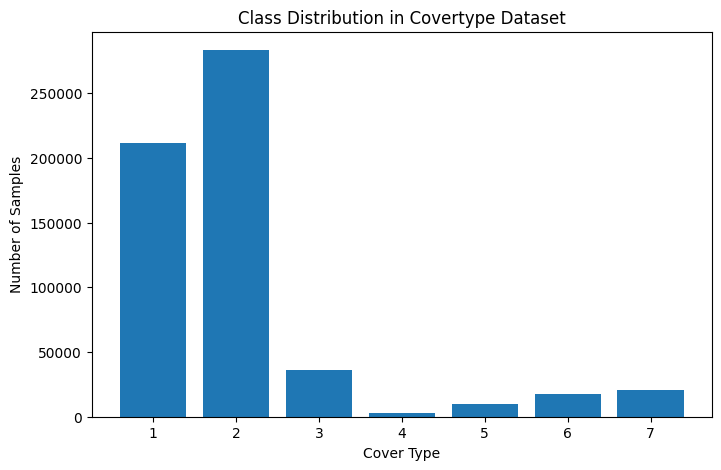

In [111]:
class_counts = y.value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Covertype Dataset")
plt.show()

In [112]:
from sklearn.model_selection import train_test_split

# split to 80% train + val and 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_cont, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# split to 70% train and 10% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,  # 10% of total
    random_state=42,
    stratify=y_temp
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (406707, 10)
Validation set shape: (58102, 10)
Test set shape: (116203, 10)


In [113]:
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method="yeo-johnson", standardize=True)

X_train_scaled = transformer.fit_transform(X_train)
X_val_scaled = transformer.transform(X_val)
X_test_scaled = transformer.transform(X_test)

In [114]:
smoothing_values = np.logspace(-12, 1, 20)

results = []

best_model = None
best_smoothing = None
best_val_f1 = -1

all_labels = np.sort(y.unique())

for s in smoothing_values:
    model = GaussianNB(var_smoothing=s)
    model.fit(X_train_scaled, y_train)

    y_val_pred = model.predict(X_val_scaled)
    y_val_prob = model.predict_proba(X_val_scaled)

    acc = accuracy_score(y_val, y_val_pred)
    precision_macro = precision_score(y_val, y_val_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_val, y_val_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    loss = log_loss(y_val, y_val_prob, labels=all_labels)

    results.append({
        "var_smoothing": s,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "log_loss": loss
    })

    if f1_macro > best_val_f1:
        best_val_f1 = f1_macro
        best_model = model
        best_smoothing = s

results_df = pd.DataFrame(results)

print("Best smoothing:", best_smoothing)
print("Best validation macro F1:", best_val_f1)
display(results_df.sort_values(by="f1_macro", ascending=False).head(10))

Best smoothing: 0.00016237767391887243
Best validation macro F1: 0.4782932865897882


,var_smoothing,accuracy,precision_macro,recall_macro,f1_macro,log_loss
12,1.623777e-04,0.654607,0.480862,0.478429,0.478293,0.821826
11,3.359818e-05,0.654590,0.480856,0.478423,0.478288,0.821849
0,1.000000e-12,0.654590,0.480837,0.478423,0.478282,0.821855
1,4.832930e-12,0.654590,0.480837,0.478423,0.478282,0.821855
3,1.128838e-10,0.654590,0.480837,0.478423,0.478282,0.821855
2,2.335721e-11,0.654590,0.480837,0.478423,0.478282,0.821855
6,1.274275e-08,0.654590,0.480837,0.478423,0.478282,0.821855
4,5.455595e-10,0.654590,0.480837,0.478423,0.478282,0.821855
7,6.158482e-08,0.654590,0.480837,0.478423,0.478282,0.821855
8,2.976351e-07,0.654590,0.480837,0.478423,0.478282,0.821855


In [115]:
print("Best smoothing value:", best_smoothing)

Best smoothing value: 0.00016237767391887243


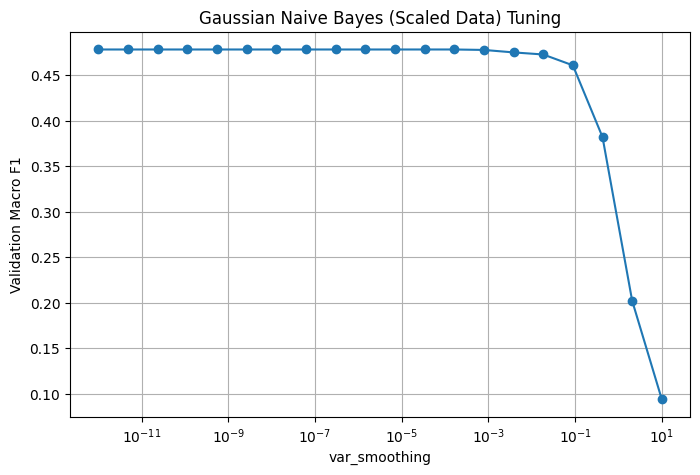

In [116]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["var_smoothing"],
    results_df["f1_macro"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("var_smoothing")
plt.ylabel("Validation Macro F1")
plt.title("Gaussian Naive Bayes (Scaled Data) Tuning")
plt.grid(True)
plt.show()

In [117]:
y_val_pred = best_model.predict(X_val_scaled)
y_val_prob = best_model.predict_proba(X_val_scaled)

# macro treats all classes equally
# weighted takes into account class imbalance

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision_macro = precision_score(y_val, y_val_pred, average="macro", zero_division=0)
val_recall_macro = recall_score(y_val, y_val_pred, average="macro", zero_division=0)
val_f1_macro = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

val_precision_weighted = precision_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_recall_weighted = recall_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_f1_weighted = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)

val_loss = log_loss(y_val, y_val_prob)

print("Validation Accuracy:", val_accuracy)
print("Validation Precision (Macro):", val_precision_macro)
print("Validation Recall (Macro):", val_recall_macro)
print("Validation F1-score (Macro):", val_f1_macro)
print("Validation Precision (Weighted):", val_precision_weighted)
print("Validation Recall (Weighted):", val_recall_weighted)
print("Validation F1-score (Weighted):", val_f1_weighted)
print("Validation Log Loss:", val_loss)

Validation Accuracy: 0.6546074145468315
Validation Precision (Macro): 0.48086193290114027
Validation Recall (Macro): 0.4784285192923086
Validation F1-score (Macro): 0.4782932865897882
Validation Precision (Weighted): 0.6508167991628354
Validation Recall (Weighted): 0.6546074145468315
Validation F1-score (Weighted): 0.651848799699197
Validation Log Loss: 0.8218257946912769


In [118]:
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.67      0.62      0.64     21184
           2       0.71      0.75      0.72     28330
           3       0.56      0.64      0.59      3576
           4       0.49      0.53      0.51       275
           5       0.23      0.20      0.22       949
           6       0.35      0.30      0.32      1737
           7       0.36      0.31      0.33      2051

    accuracy                           0.65     58102
   macro avg       0.48      0.48      0.48     58102
weighted avg       0.65      0.65      0.65     58102



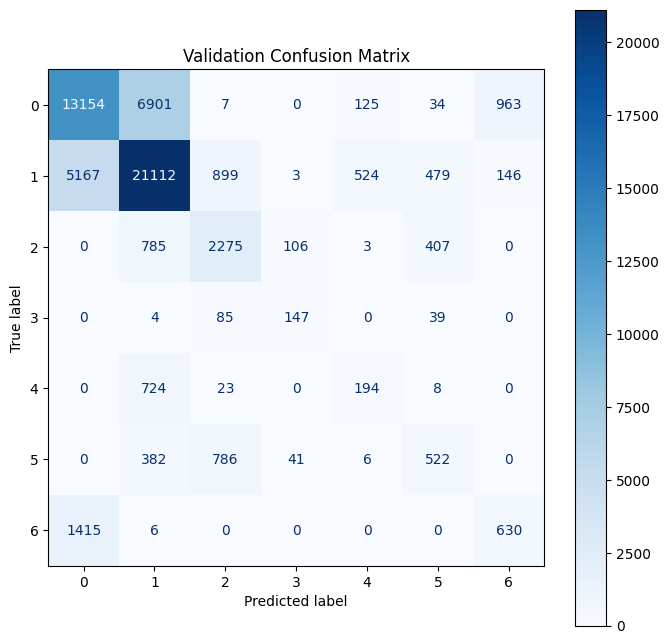

In [119]:
cm_val = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Validation Confusion Matrix")
plt.show()

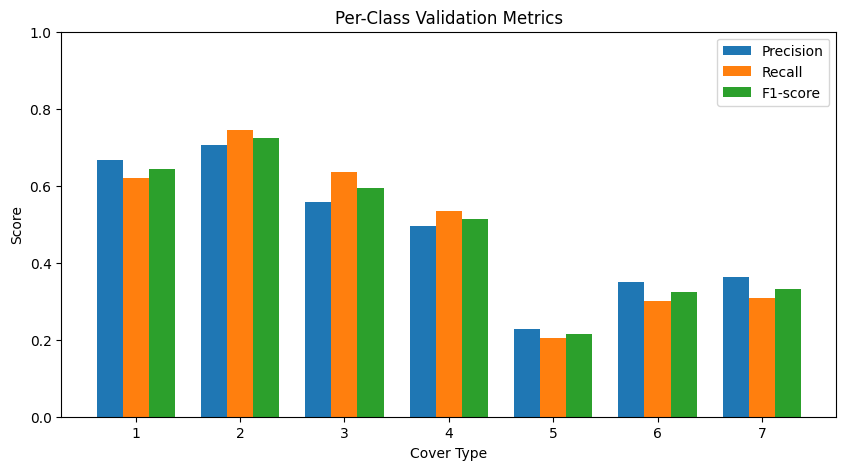

In [120]:
report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)

classes = [str(i) for i in sorted(y.unique())]
precisions = [report[c]["precision"] for c in classes]
recalls = [report[c]["recall"] for c in classes]
f1s = [report[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precisions, width=width, label="Precision")
plt.bar(x, recalls, width=width, label="Recall")
plt.bar(x + width, f1s, width=width, label="F1-score")

plt.xticks(x, classes)
plt.xlabel("Cover Type")
plt.ylabel("Score")
plt.title("Per-Class Validation Metrics")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [121]:
fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

train_accs = []
val_accs = []
train_losses = []
val_losses = []

rng = np.random.default_rng(42)
indices = rng.permutation(len(X_train_scaled))

X_train_shuffled = X_train_scaled[indices]
y_train_shuffled = y_train.iloc[indices].reset_index(drop=True)

for frac in fractions:
    n = int(len(X_train_shuffled) * frac)

    X_sub = X_train_shuffled[:n]
    y_sub = y_train_shuffled.iloc[:n]

    model = GaussianNB(var_smoothing=best_smoothing)
    model.fit(X_sub, y_sub)

    y_sub_pred = model.predict(X_sub)
    y_sub_prob = model.predict_proba(X_sub)

    y_val_pred_frac = model.predict(X_val_scaled)
    y_val_prob_frac = model.predict_proba(X_val_scaled)

    train_accs.append(accuracy_score(y_sub, y_sub_pred))
    val_accs.append(accuracy_score(y_val, y_val_pred_frac))
    train_losses.append(log_loss(y_sub, y_sub_prob, labels=all_labels))
    val_losses.append(log_loss(y_val, y_val_prob_frac, labels=all_labels))

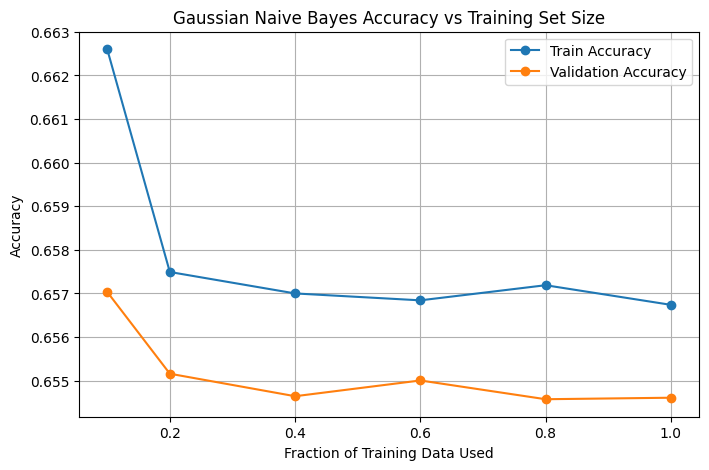

In [122]:
plt.figure(figsize=(8, 5))
plt.plot(fractions, train_accs, marker='o', label="Train Accuracy")
plt.plot(fractions, val_accs, marker='o', label="Validation Accuracy")
plt.xlabel("Fraction of Training Data Used")
plt.ylabel("Accuracy")
plt.title("Gaussian Naive Bayes Accuracy vs Training Set Size")
plt.legend()
plt.grid(True)
plt.show()

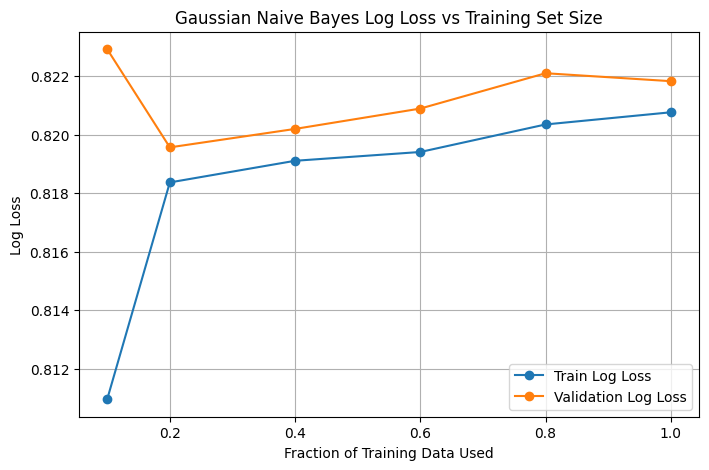

In [123]:
plt.figure(figsize=(8, 5))
plt.plot(fractions, train_losses, marker='o', label="Train Log Loss")
plt.plot(fractions, val_losses, marker='o', label="Validation Log Loss")
plt.xlabel("Fraction of Training Data Used")
plt.ylabel("Log Loss")
plt.title("Gaussian Naive Bayes Log Loss vs Training Set Size")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
y_test_pred = best_model.predict(X_test_scaled)
y_test_prob = best_model.predict_proba(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision_macro = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

test_precision_weighted = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_recall_weighted = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_weighted = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

test_loss = log_loss(y_test, y_test_prob)

print("Test Accuracy:", test_accuracy)
print("Test Precision (Macro):", test_precision_macro)
print("Test Recall (Macro):", test_recall_macro)
print("Test F1-score (Macro):", test_f1_macro)
print("Test Precision (Weighted):", test_precision_weighted)
print("Test Recall (Weighted):", test_recall_weighted)
print("Test F1-score (Weighted):", test_f1_weighted)
print("Test Log Loss:", test_loss)

Test Accuracy: 0.6555854840236482
Test Precision (Macro): 0.48401218091887294
Test Recall (Macro): 0.4720065238640046
Test F1-score (Macro): 0.4766089620792143
Test Precision (Weighted): 0.6522810746525917
Test Recall (Weighted): 0.6555854840236482
Test F1-score (Weighted): 0.6531048754616655
Test Log Loss: 0.8221056751282847


In [125]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.67      0.63      0.65     42368
           2       0.71      0.74      0.72     56661
           3       0.55      0.63      0.59      7151
           4       0.46      0.43      0.45       549
           5       0.25      0.24      0.25      1899
           6       0.37      0.32      0.35      3473
           7       0.38      0.31      0.34      4102

    accuracy                           0.66    116203
   macro avg       0.48      0.47      0.48    116203
weighted avg       0.65      0.66      0.65    116203



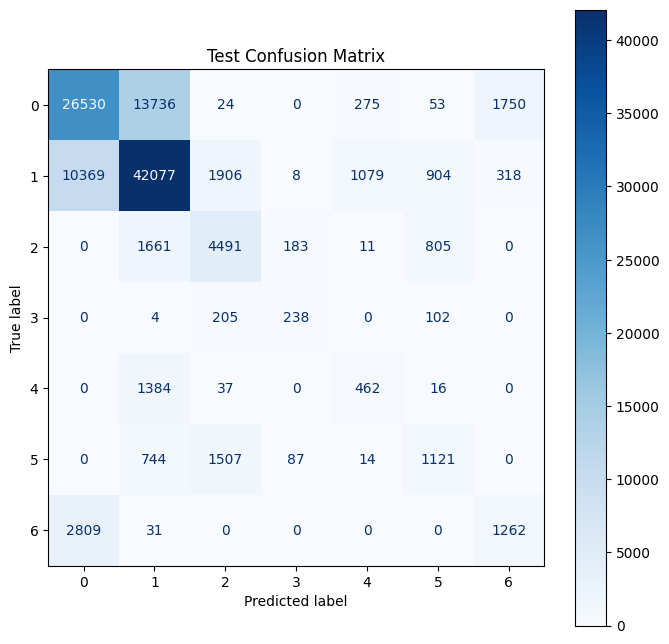

In [126]:
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix")
plt.show()

In [127]:
baseline_results = evaluate_model(best_model, X_test_scaled, y_test, label="Baseline Continuous Test")
baseline_y_pred = baseline_results["y_pred"]

Baseline Continuous Test Accuracy: 0.6555854840236482
Baseline Continuous Test Precision (Macro): 0.48401218091887294
Baseline Continuous Test Recall (Macro): 0.4720065238640046
Baseline Continuous Test F1-score (Macro): 0.4766089620792143
Baseline Continuous Test Precision (Weighted): 0.6522810746525917
Baseline Continuous Test Recall (Weighted): 0.6555854840236482
Baseline Continuous Test F1-score (Weighted): 0.6531048754616655
Baseline Continuous Test Log Loss: 0.8221056751282847
